In [19]:
import os
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict
from daemon_analysis_tools.io.yaml_handler import load_answers_from_yaml
from daemon_analysis_tools.io.csv_handler import _load_csv

In [20]:
csv_read = _load_csv("../../data/metadata/journal_selection.csv")

impact_factor_dict = {}
for journal, impact_factor in zip(csv_read["title"], csv_read["citations_avg"]):
    impact_factor_dict[journal.lower().replace(" ", "_")] = impact_factor

print(impact_factor_dict)
#print(csv_read["title"], csv_read["citations_avg"], csv_read["citations_median"])


[info] CSV loaded ← ../../data/metadata/journal_selection.csv
{'escience': 47.79047619047619, 'applied_catalysis_b_environmental': 39.88368891947695, 'energy_storage_materials': 28.907997169143663, 'nano_energy': 29.69001610305958, 'food_hydrocolloids': 27.77777777777778, 'advanced_powder_materials': 47.19642857142857, 'joule': 43.5125348189415, 'ssrn_electronic_journal': 0.1664711127798376, 'materials_today_proceedings': 5.190393518518518, 'chemical_engineering_journal': 21.943821038152464, 'journal_of_alloys_and_compounds': 10.656837506825806, 'ceramics_international': 8.925697674418604, 'bioactive_materials': 22.83080808080808, 'composites_part_a_applied_science_and_manufacturing': 14.213085764809902, 'materials_science_and_engineering_a': 11.167504630854724, 'superlattices_and_microstructures': 9.12735849056604, 'materials_today_bio': 8.105442176870747, 'accounts_of_chemical_research': 29.07106598984772, 'acs_energy_letters': 27.080745341614907, 'journal_of_the_american_chemical_so

In [21]:
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12
LINE_WIDTH = 1.5
MARKER_SIZE = 6

plt.rc("font", **{"family": "sans-serif", "sans-serif": ["Liberation Sans"]})
plt.rc("font", family="sans-serif", weight="bold", size=MEDIUM_SIZE)

plt.rc("axes", titlesize=MEDIUM_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)

mpl.rcParams["font.weight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
mpl.rcParams["mathtext.default"] = "regular"
mpl.rcParams["lines.linewidth"] = LINE_WIDTH
mpl.rcParams["lines.markersize"] = MARKER_SIZE

In [22]:
# Load all the processed yaml files 
processed_data = load_answers_from_yaml('../../data/processed/all_answers/')


No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
N

In [23]:
from daemon_analysis_tools.services.scoring import get_question_score, _get_question_type_lookup
from daemon_analysis_tools.io.yaml_base_handler import load_yaml

data_dir = os.path.join("..", "..", "src/daemon_analysis_tools/metadata")

multiple_choice_scores = load_yaml(
    os.path.join(data_dir, "question_metadata_score.yaml")
)
question_type = load_yaml(os.path.join(data_dir, "question_type.yaml"))
question_number_lookup = _get_question_type_lookup(multiple_choice_scores)

score_dict = defaultdict(list)

n_journals = 0

for publisher, publisher_results in processed_data.items():
    for journal, journal_results in publisher_results.items():
        n_journals += 1

        for question, answer in journal_results.items():
            if not question in score_dict:
                score_dict[question] = []

            question_score = get_question_score(question,
                                                answer,
                                                multiple_choice_scores,
                                                question_type,
                                                question_number_lookup,)

            score_dict[question].append(question_score)

# Compute mean and std
exclude_questons = ["data_recommended", "data_required"]

mean_std_dict = {}
for q, vals in score_dict.items():
    if q in exclude_questons:
        continue

    mean_std_dict[q] = (np.mean(vals), np.std(vals))

# Sort by mean
sorted_items = sorted(mean_std_dict.items(), key=lambda item: item[1][0], reverse=True)

labels = [q.replace("_", " ") for q, _ in sorted_items]
means = [m for _, (m, s) in sorted_items]
stds = [s for _, (m, s) in sorted_items]

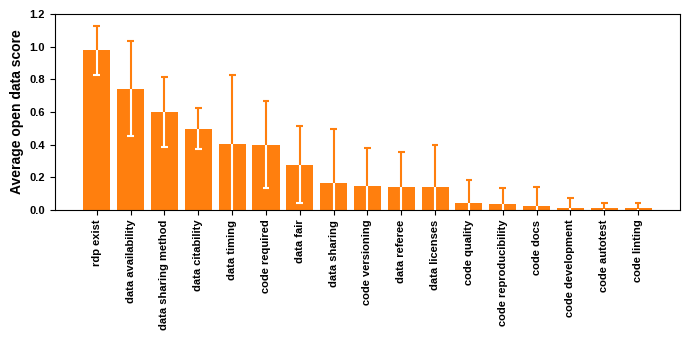

In [24]:
fig, ax = plt.subplots(figsize=(7, 3.5))

bar_color = "C1"

# Plot bars without outline
bars = ax.bar(labels, 0.01, color=bar_color, edgecolor="none")
bars = ax.bar(labels, means, color=bar_color, edgecolor="none")

# Add custom split error bars
for i, (mean, std) in enumerate(zip(means, stds)):
    if mean == 0:
        continue

    # Upper error bar (same color as bar)
    ax.vlines(i, mean, mean + std, color=bar_color, linewidth=1.5, zorder=3)
    ax.hlines(mean + std, i - 0.1, i + 0.1, color=bar_color, linewidth=1.5, zorder=3)

    # Lower error bar (white)
    ax.vlines(i, mean - std, mean, color="white", linewidth=1.5, zorder=3)
    ax.hlines(mean - std, i - 0.1, i + 0.1, color="white", linewidth=1.5, zorder=3)

ax.set_ylabel("Average open data score")
plt.xticks(rotation=90)

plt.ylim((0.0, 1.2))

plt.tight_layout()

fig.savefig("../../data/processed/average_score_per_question.pdf")

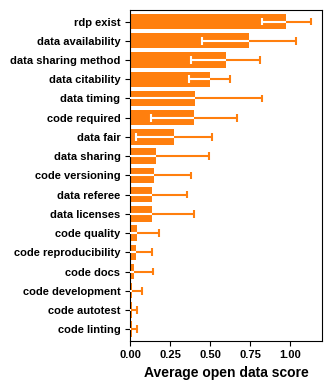

In [25]:
labels = labels[::-1]
means = means[::-1]
stds = stds[::-1]

fig, ax = plt.subplots(figsize=(3.5, 4))

bar_color = "C1"

# Plot bars without outline (horizontal bars)
bars = ax.barh(labels, [0.01]*len(means), color=bar_color, edgecolor="none")
bars = ax.barh(labels, means, color=bar_color, edgecolor="none")

# Add custom split error bars
for i, (mean, std) in enumerate(zip(means, stds)):
    if mean == 0:
        continue

    # Upper error bar (to the right, same color as bar)
    ax.hlines(i, mean, mean + std, color=bar_color, linewidth=1.5, zorder=3)
    ax.vlines(mean + std, i - 0.2, i + 0.2, color=bar_color, linewidth=1.5, zorder=3)

    # Lower error bar (to the left, white)
    ax.hlines(i, mean - std, mean, color="white", linewidth=1.5, zorder=3)
    ax.vlines(mean - std, i - 0.2, i + 0.2, color="white", linewidth=1.5, zorder=3)

ax.set_xlabel("Average open data score")
ax.set_xlim((0.0, 1.2))
ax.set_ylim((-0.6, 16.6))
plt.tight_layout()

fig.savefig("../../data/processed/average_score_per_question_one_column.pdf")
